# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Zahara Seybou Harouna
**Student ID:** 30862027

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

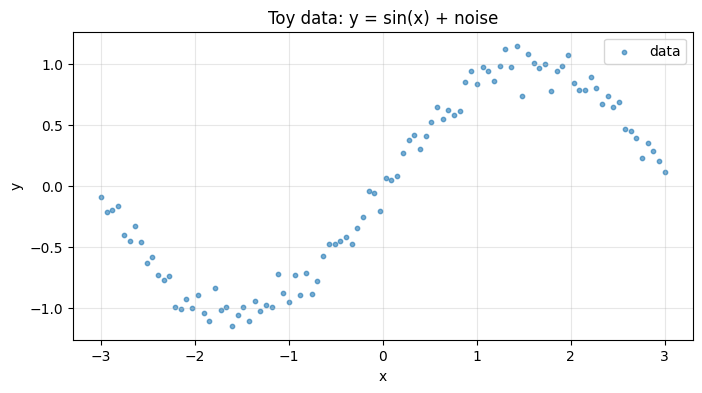

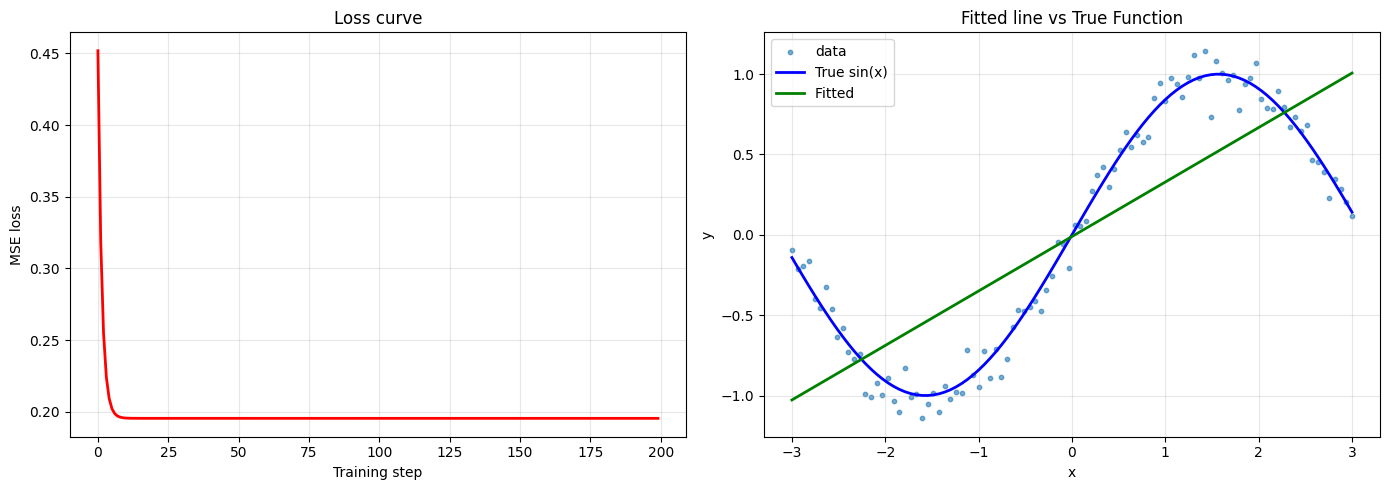

Final loss:  0.1955
Learned w:  0.3390
Learned b: -0.0104


In [7]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = (np.sin(x.flatten()) + np.random.normal(0, 0.1, size=100)).reshape(-1, 1)
#   Plot it.
plt.figure(figsize=(8, 4))
plt.scatter(x, y,s=10, alpha=0.6, label="data")
plt.title("Toy data: y = sin(x) + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w = np.random.randn(1, 1) * 0.1
b = np.zeros(1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.05
losses = []
for step in range(200):
#   y_hat = w * x + b
  y_hat = x @ w + b
#   loss  = np.mean((y_hat - y) ** 2)
  error = y_hat - y
  loss = float(np.mean(error ** 2))
  losses.append(loss)              # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)
  dw = float(np.mean(2 * error* x))            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))
  db = float(np.mean(2 * error))               # dLoss/db
#   w    -= lr * dw
  w -= lr * dw
#   b    -= lr * db
  b -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(losses, color= 'red', linewidth=2)
ax1.set_title("Loss curve")
ax1.set_xlabel("Training step")
ax1.set_ylabel("MSE loss")
ax1.grid(True, alpha=0.3)

ax2.scatter(x, y, s=10, alpha=0.6, label="data")
ax2.plot(x, np.sin(x), color='blue', linewidth=2, label="True sin(x)")
ax2.plot(x, x @ w + b, color='green', linewidth=2, label="Fitted ")
ax2.set_title("Fitted line vs True Function")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]: .4f}")
print(f"Learned w: {w[0, 0]: .4f}")
print(f"Learned b: {b[0]: .4f}")


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
Loss = (1/n)* sum(y_hat - y
)^2
y_hat = w * x * b
dLoss/dw = mean(2*(y_hat - y) * x)
Yes it does match the code.
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*
This is underfitting. The single neuron computes y_hat = w*x+b a straight line. No matter how long we train, a linear function can never represent a non-linear sine wave. The model's hypothesis space simply does not contain the true function (sin(x)). his is a capacity problem — the model is too simple, not a data problem. Adding more training steps cannot fix underfitting we need a more complexe model(non linear activation).



### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Parameter shape: 
W1: (1, 8)
b1: (8,)
W2: (8, 1)
b2: (1,)

Total parameters: 25


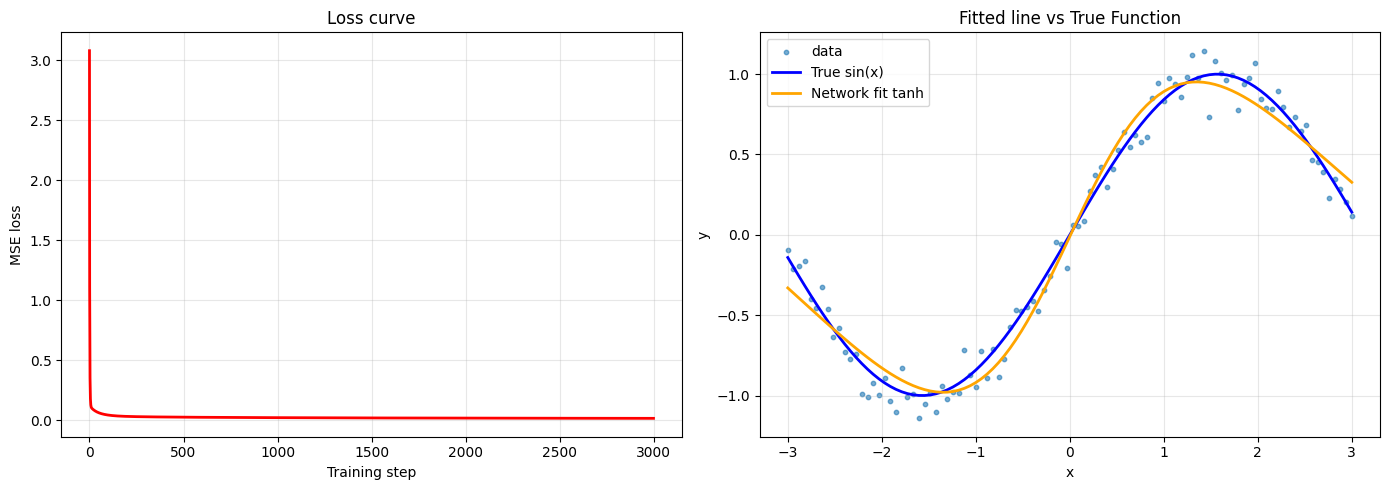

Final loss:  0.0150


In [9]:
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)
#   W1: shape (1, 8),  b1: shape (8,)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
#   W2: shape (8, 1),  b2: shape (1,)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)
lr = 0.05
print("Parameter shape: ")
print(f"W1: {W1.shape}")
print(f"b1: {b1.shape}")
print(f"W2: {W2.shape}")
print(f"b2: {b2.shape}")
total_params = W1.size + b1.size + W2.size + b2.size
print(f"\nTotal parameters: {total_params}")
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~3000 steps:
losses_tahn = []
for step in range(3000):
#   Small random values (e.g. np.random.randn(...) * 0.5)
# TODO: Forward pass (keep the intermediate values — you need them for backprop):

#   z1 = x @ W1 + b1
  z1 = x @ W1 + b1       # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)
  h = np.tanh(z1)       # activation
#   y_hat = h @ W2 + b2
  y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
  loss = float(np.mean((y_hat - y) ** 2))
  losses_tahn.append(loss)
# TODO: Backward pass (the chain rule, layer by layer):

#   d_yhat = 2 * (y_hat - y) / len(y)
  d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dW2 = h.T @ d_yhat ;
#   dh  = d_yhat @ W2.T
  dh = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)
  dz1 = dh * (1- np.tanh(z1)**2)    # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
  dW1 = x.T @ dz1 ;
  db1 = dz1.sum(axis=0)
  db2 = d_yhat.sum(axis=0)
# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W2 -= lr * dW2
  b2 -= lr * db2
  W1 -= lr * dW1
  b1 -= lr * db1
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(losses_tahn, color= 'red', linewidth=2)
ax1.set_title("Loss curve")
ax1.set_xlabel("Training step")
ax1.set_ylabel("MSE loss")
ax1.grid(True, alpha=0.3)

y_hat_final = np.tanh(x @ W1 + b1) @ W2 + b2
ax2.scatter(x, y, s=10, alpha=0.6, label="data")
ax2.plot(x, np.sin(x), color='blue', linewidth=2, label="True sin(x)")
ax2.plot(x, y_hat_final, color='orange', linewidth=2, label="Network fit tanh")
ax2.set_title("Fitted line vs True Function")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final loss: {losses_tahn[-1]: .4f}")


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Mathematically, linear functions always produces another linear function. For example if layer 1 computes y= w1*x + b1 and layer 2 computer W2(w1*x +b1) + b2 = (w2*w1)* x + (W2*b1 + b2) it will just be y = W_eff *x + b_eff a single linear layer. No matter how many linear layers we stack, the entire network is equivalent to one linear transformation.
*2. Each of the 8 hidden neurons learned a different tanh-shaped "bump" function centered at a different position along x. The output layer then learned to combine these 8 bumps with different weights to approximate the full sine wave. This is a practical demonstration of the Universal Approximation
Theorem. Each hidden layer contributed a piece that the output layer put together.
*3. Backpropagation is the algorithm that applies the chain rule layer by layer starting from the output loss and propagating gradients backware through every weight in the network to efficiently compute the how much each weight contributed to the error so we can update them all in one pass.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

Training with lr = 0.001
Training with lr = 0.05
Training with lr = 1.0


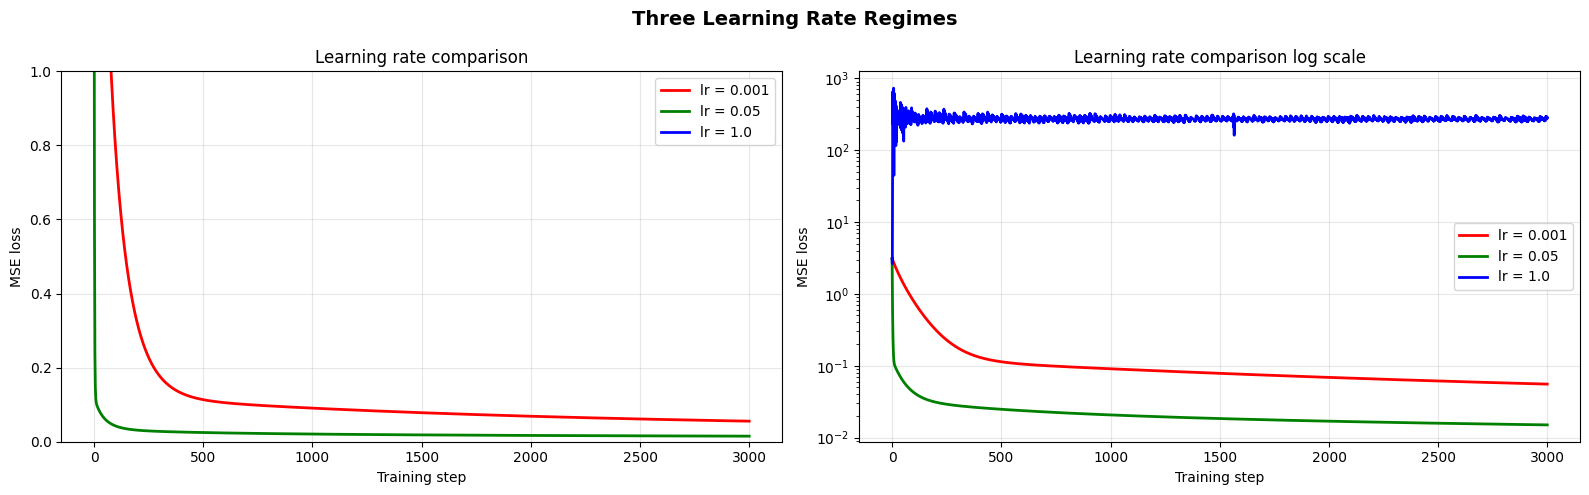

Final loss:  0.055496
Final loss:  0.015034
Final loss:  280.948247


In [15]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000, clip_value=5.0):
  np.random.seed(RANDOM_STATE)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)
  losses = []
  for step in range(steps):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    raw_loss = np.mean((y_hat - y) ** 2)
    if np.isnan(raw_loss) or np.isinf(raw_loss):
      losses.append(float("inf"))
      break
    losses.append(float(raw_loss))

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    dh = d_yhat @ W2.T
    dz1 = dh * (1- np.tanh(z1)**2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)
    db2 = d_yhat.sum(axis=0)
    for grad in [dW1, db1, dW2, db2]:
      np.clip(grad, -clip_value, clip_value, out=grad)
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1
  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
print("Training with lr = 0.001")
losses_lr_001 = train_toy(lr = 0.001, steps = 3000)
print("Training with lr = 0.05")
losses_lr_05 = train_toy(lr=0.05, steps=3000)
print("Training with lr = 1.0")
losses_lr_1 = train_toy(lr=1.0, steps=3000)
def clean_losses(losses):
    cleaned = []
    last_valid = losses[0] if losses else 1.0
    for l in losses:
        if np.isfinite(l):
            cleaned.append(l)
            last_valid = l
        else:
            cleaned.append(last_valid * 10)
    return cleaned

losses_large = clean_losses(losses_lr_1)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(losses_lr_001, color= 'red', linewidth=2, label="lr = 0.001")
ax1.plot(losses_lr_05, color= 'green', linewidth=2, label="lr = 0.05")
ax1.plot(losses_lr_1, color= 'blue', linewidth=2, label="lr = 1.0")
ax1.set_title("Learning rate comparison")
ax1.set_xlabel("Training step")
ax1.set_ylabel("MSE loss")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 1)
ax2.semilogy(losses_lr_001, color= 'red', linewidth=2, label="lr = 0.001")
ax2.semilogy(losses_lr_05, color= 'green', linewidth=2, label="lr = 0.05")
ax2.semilogy(losses_lr_1, color= 'blue', linewidth=2, label="lr = 1.0")
ax2.set_title("Learning rate comparison log scale")
ax2.set_xlabel("Training step")
ax2.set_ylabel("MSE loss")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle("Three Learning Rate Regimes",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Final loss: {losses_lr_001[-1]: .6f}")
print(f"Final loss: {losses_lr_05[-1]: .6f}")
print(f"Final loss: {losses_lr_1[-1]: .6f}")

**Student Reasoning — Learning rate**
lr = 0.001
The network learns painfully slowly, each gradient step moves only a tiny distance down the loss surface.This means extremely long
training times and risk of stopping before convergence.

lr = 0.5
The network converges smoothly and quickly to the lowest loss
(~0.015). Steps are large enough to make rapid progress but small enough not to overshoot the minimum.The loss curve drops steeply then plateaus cleanly.

lr = 1.0
The updates are so large that the weights overshoot the minimum completely like trying to walk downhill by taking giant leaps and ending up on the other side of the valley. The final loss exploded to ~280, causing a RuntimeWarning: overflow in NumPy because floating point numbers couldn't store the values.
This is exploding gradients in action.



---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [17]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
print(f"Dataset shape: {obesity.shape}")
print(f"\nFirst few rows:")
print(obesity.head())
print(f"\nTarget classes:")
print(obesity["NObeyesdad"].value_counts())
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)
bin_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in bin_cols:
  obesity[col] = obesity[col].map({"yes": 1, "no": 0})
ordinal_mapping = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(ordinal_mapping)
obesity["CALC"] = obesity["CALC"].map(ordinal_mapping)
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"],
                         drop_first=True)
le = LabelEncoder()
obesity["NObeyesdad_enc"] = le.fit_transform(obesity["NObeyesdad"])
print(f"\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\nTotal NaN values: {obesity.isnull().sum().sum()}")
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns=["NObeyesdad", "NObeyesdad_enc"])
y_labels = obesity["NObeyesdad_enc"].values
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_labels,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"\nSplit sizes:")
print(f"  Train: {X_train_scaled.shape[0]} rows")
print(f"  Val:   {X_val_scaled.shape[0]} rows")
print(f"  Test:  {X_test_scaled.shape[0]} rows")
print(f"  Features: {X_train_scaled.shape[1]}")
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val_scaled,dtype=torch.float32)
y_val_t   = torch.tensor(y_val,dtype=torch.long)

X_test_t  = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader  = DataLoader(val_dataset, batch_size=64, shuffle=False)
print(f"\nTensor shapes:")
print(f"  X_train_t: {X_train_t.shape}")
print(f"  y_train_t: {y_train_t.shape}")
print(f"Training samples: {len(train_dataset)}")
print(f"Number of batches per epoch: {len(train_loader)}")
print(f"\nData ready for PyTorch!")

Dataset shape: (2111, 17)

First few rows:
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Norma

**Student Reasoning — Preprocessing for neural networks**
*1. In PyTorch, nn CrossEntropyLoss combines nn.LogSoftmax and nn NLLLoss (Negative Log Likelihood Loss) into a single layer for numerical stability. Because the target loss formula only requires indexing the log-probability of the true target class, passing integer class indices directly allows PyTorch to efficiently gather the predicted logit corresponding to the ground-truth label without wasting memory or performing redundant floating-point multiplications on zeros from a one-hot vector.
*2. Decision trees and random forests rely on non-parametric axis-aligned splits along individual features, making them invariant to monotonic feature scaling. As derived from section 1 Unscaled features with large numerical ranges create disproportionately steep gradients, leading to asymmetric loss surfaces, gradient explosion, or erratic updates, whereas features with tiny ranges receive negligible updates. Feature scaling ensures balanced loss contours, enabling uniform gradient descent updates across all parameters.
*3. Setting shuffle=True reorganizes the order of training samples at the start of every epoch, ensuring that each mini-batch consists of a different random grouping of data points. This prevents the optimizer from getting trapped in repeating cyclic patterns or localized parameter oscillations caused by fixed batch orderings, reduces gradient variance across epochs, and helps stochastic gradient descent generalize better and converge toward a global minimum.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [18]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(hidden_sizes[1], n_classes)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        logits = self.out(x)
        return logits
# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")
first_layer_weights = input_dim * 64
first_layer_biases = 64
first_layer_total = first_layer_weights + first_layer_biases
print(f"By-hand count for Layer 1 ({input_dim} inputs -> 64 outputs): {first_layer_total}")

FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters: 3655
By-hand count for Layer 1 (20 inputs -> 64 outputs): 1344


**Student Reasoning — Architecture**
*1. Assuming an input dimension of 20 features (after encoding categoricals):Layer 1 (fc1):
20 inputs * 64 neuron + 64 bias= 1088
layer2: 64 inputs * 32neurons + 32 bias = 2080
Output layer:
32 input * 7classes + 7 bias = 231
total param = 3655 which matches.
*2. One key advantage of ReLU (max(0, x)) over tanh is that its gradient is always 1 for all positive inputs (x > 0), which actively mitigates the vanishing gradient problem during backpropagation. Unlike tanh, which saturates for inputs outside [-2, 2] (causing gradients to shrink near zero), ReLU maintains a constant gradient slope, allowing faster and more reliable optimization in deeper networks.
*3. If the non-linear activation functions (ReLUs) are removed, the network becomes a succession of linear transformations. Because matrix multiplication is associative, this entire chain collapses mathematically into a single linear transformation.



### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8693 | Train Acc: 0.2370 | Val Loss: 1.7588 | Val Acc: 0.3578
Epoch 05/50 | Train Loss: 0.7207 | Train Acc: 0.7622 | Val Loss: 0.6646 | Val Acc: 0.7701
Epoch 10/50 | Train Loss: 0.3114 | Train Acc: 0.9210 | Val Loss: 0.3267 | Val Acc: 0.9028
Epoch 15/50 | Train Loss: 0.1696 | Train Acc: 0.9621 | Val Loss: 0.2302 | Val Acc: 0.9313
Epoch 20/50 | Train Loss: 0.1090 | Train Acc: 0.9834 | Val Loss: 0.1977 | Val Acc: 0.9336
Epoch 25/50 | Train Loss: 0.0714 | Train Acc: 0.9913 | Val Loss: 0.1844 | Val Acc: 0.9360
Epoch 30/50 | Train Loss: 0.0508 | Train Acc: 0.9921 | Val Loss: 0.1932 | Val Acc: 0.9360
Epoch 35/50 | Train Loss: 0.0370 | Train Acc: 0.9953 | Val Loss: 0.1772 | Val Acc: 0.9479
Epoch 40/50 | Train Loss: 0.0273 | Train Acc: 0.9992 | Val Loss: 0.1896 | Val Acc: 0.9431
Epoch 45/50 | Train Loss: 0.0205 | Train Acc: 0.9992 | Val Loss: 0.1950 | Val Acc: 0.9408
Epoch 50/50 | Train Loss: 0.0155 | Train Acc: 1.0000 | Val Loss: 0.1991 | Val Acc: 0.9431


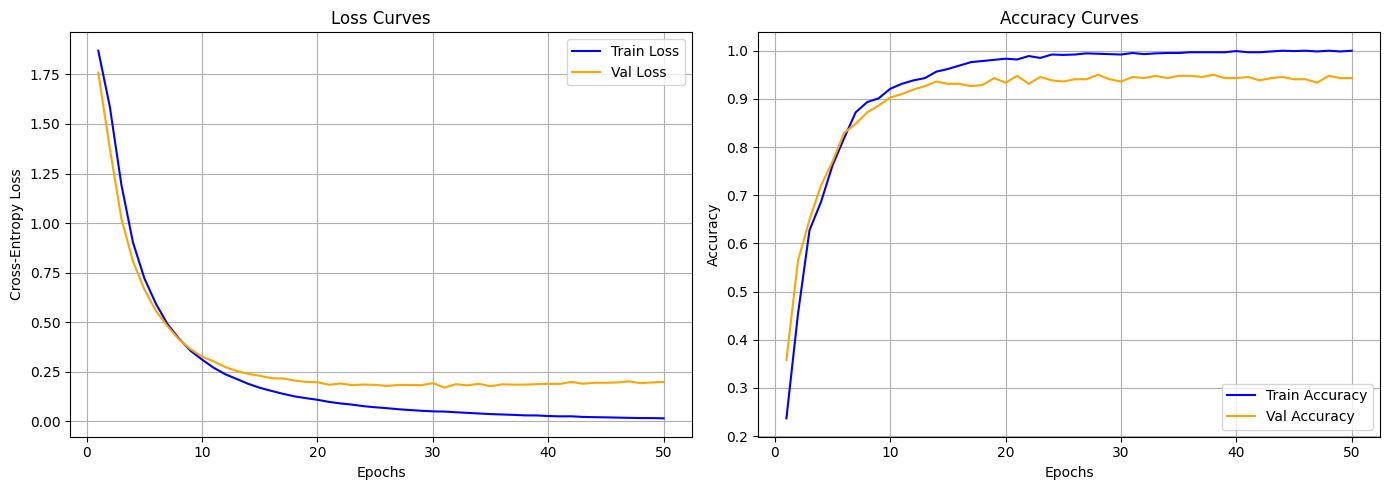

In [19]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_acc = 0.0
EPOCHS = 50
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            running_val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color='blue')
ax1.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', color='orange')
ax1.set_title("Loss Curves")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Accuracy', color='orange')
ax2.set_title("Accuracy Curves")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.